# Analyst-Forecast-Based Equity Duration (FcstD)

This notebook computes equity duration based on analyst consensus forecasts
(Cash EPS, DPS) for Euro Stoxx 500 firms, following the clean-surplus framework
of Dechow, Sloan & Soliman (2004) with Jensen-inequality corrections from
Goncalves (2021).

Duration is computed via the numerical derivative of a Residual Income Model
pricing function (Schroder & Esterer 2016), with the discount rate solved
endogenously as the implied cost of capital (ICC).

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from plot_style import COLORS, set_global_plot_style, style_axes, save_figure as _ps_save_figure

set_global_plot_style()

from project_paths import BASE_DIR, DATA_DIR, GRAPH_DIR

def save_parquet(df: pd.DataFrame, name: str):
    path = DATA_DIR / f"{name}.parquet"
    df.to_parquet(path, index=False)
    print(f"Saved: {path}")

def load_parquet(name: str) -> pd.DataFrame:
    path = DATA_DIR / f"{name}.parquet"
    return pd.read_parquet(path)

NOTEBOOK_GRAPH_DIR = GRAPH_DIR / "EQDuration_AnalystBased"
NOTEBOOK_GRAPH_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, name: str):
    path = NOTEBOOK_GRAPH_DIR / f"{name}.png"
    _ps_save_figure(fig, path, dpi=220)
    print(f"Saved figure: {path}")

## 1. Load Data

We load the analyst-based panel (`euro500_analystbased.parquet`) and the
net-payout duration output (`EQDuration_Netpayout.parquet`) for cross-validation.

In [2]:
raw = load_parquet("euro500_analystbased")
print(f"Loaded euro500_analystbased: {raw.shape[0]:,} rows, {raw.shape[1]} cols")
print(f"Firms: {raw['firm_id'].nunique():,}  |  Date range: {raw['date'].min()} – {raw['date'].max()}")

# Discount rate panel for Jensen corrections
np_out = load_parquet("EQDuration_Netpayout")
print(f"\nLoaded EQDuration_Netpayout: {np_out.shape[0]:,} rows")

Loaded euro500_analystbased: 13,796 rows, 23 cols
Firms: 1,120  |  Date range: 1998-12-31 00:00:00 – 2024-12-31 00:00:00

Loaded EQDuration_Netpayout: 12,073 rows


## 2. Sample Restrictions

Sequential filters: post-1998 (I/B/E/S coverage), positive book equity,
positive market equity, at least FY1 Cash EPS forecast available.

In [3]:
df = raw.copy()
df["year"] = df["date"].dt.year

n0 = len(df)
funnel = [("Raw input", n0)]

# 1) Drop years before 1998
df = df[df["year"] >= 1998].copy()
n1 = len(df)
funnel.append(("year >= 1998", n1))
print(f"Filter 1 (year >= 1998): {n0 - n1:,} dropped, {n1:,} remaining")

# 2) NumAnalysts_fy1 >= 3
df = df[df["NumAnalysts_fy1"] >= 3].copy()
n2 = len(df)
funnel.append(("NumAnalysts_fy1 >= 3", n2))
print(f"Filter 2 (NumAnalysts >= 3): {n1 - n2:,} dropped, {n2:,} remaining")

# 3) EPS_fy1_est not NaN (primary input for duration)
df = df[df["EPS_fy1_est"].notna()].copy()
n3 = len(df)
funnel.append(("EPS_fy1_est not NaN", n3))
print(f"Filter 3 (EPS_fy1 not NaN): {n2 - n3:,} dropped, {n3:,} remaining")

# 4) BE > 0, ME > 0, shares_outstanding > 0
df = df[(df["BE"] > 0) & (df["ME"] > 0) & (df["shares_outstanding"] > 0)].copy()
n4 = len(df)
funnel.append(("BE > 0 & ME > 0 & shares > 0", n4))
print(f"Filter 4 (positive BE/ME/shares): {n3 - n4:,} dropped, {n4:,} remaining")

print(f"\nFinal sample: {n4:,} firm-years, {df['firm_id'].nunique():,} unique firms")

# Funnel table
funnel_df = pd.DataFrame(funnel, columns=["Step", "Firm-years"])
funnel_df["Dropped"] = funnel_df["Firm-years"].diff().fillna(0).astype(int) * -1
funnel_df.loc[0, "Dropped"] = 0
print("\n" + funnel_df.to_string(index=False))

Filter 1 (year >= 1998): 0 dropped, 13,796 remaining
Filter 2 (NumAnalysts >= 3): 2,326 dropped, 11,470 remaining
Filter 3 (EPS_fy1 not NaN): 4 dropped, 11,466 remaining
Filter 4 (positive BE/ME/shares): 357 dropped, 11,109 remaining

Final sample: 11,109 firm-years, 849 unique firms

                        Step  Firm-years  Dropped
                   Raw input       13796        0
                year >= 1998       13796        0
        NumAnalysts_fy1 >= 3       11470     2326
         EPS_fy1_est not NaN       11466        4
BE > 0 & ME > 0 & shares > 0       11109      357


## 3. Industry ROE

Trailing 5-year median ROE by TRBC sector, following Gebhardt et al. (2001).
This is the reversion target for the transition zone (h=4..10).

In [4]:
# 3a. Verify trbc_sector availability
print(f"trbc_sector coverage: {df['trbc_sector'].notna().sum()} / {len(df)} "
      f"({df['trbc_sector'].notna().mean():.1%})")
print(df["trbc_sector"].value_counts())

# 3b. Compute current ROE proxy from FY1 analyst forecasts
# We use FY1 forecast ROE as a proxy for current ROE. This is the
# closest-to-realized estimate available in the analyst-based panel.
df["ROE_current"] = (df["EPS_fy1_est"] * df["shares_outstanding"]) / df["BE"]

# 3c. Trailing 5-year median ROE by TRBC sector
# Winsorize ROE at 1st/99th before computing industry medians
roe_for_industry = df[["firm_id", "year", "trbc_sector", "ROE_current"]].copy()
q01 = roe_for_industry["ROE_current"].quantile(0.01)
q99 = roe_for_industry["ROE_current"].quantile(0.99)
roe_for_industry["ROE_current"] = roe_for_industry["ROE_current"].clip(q01, q99)
print(f"\nROE_current winsorized at [{q01:.4f}, {q99:.4f}]")

# Compute trailing 5-year median by sector
industry_roe = {}
for year in sorted(df["year"].unique()):
    window = roe_for_industry[
        (roe_for_industry["year"] >= year - 4) &
        (roe_for_industry["year"] <= year)
    ]
    medians = window.groupby("trbc_sector")["ROE_current"].median()
    for sector, med_roe in medians.items():
        industry_roe[(sector, year)] = med_roe

df["industry_roe"] = df.apply(
    lambda row: industry_roe.get((row["trbc_sector"], row["year"]), np.nan),
    axis=1,
)

# 3d. Handle edge cases
# Fallback: if industry_roe is NaN, use cross-sectional median for that year
year_medians = df.groupby("year")["industry_roe"].transform("median")
df["industry_roe"] = df["industry_roe"].fillna(year_medians)

# Floor negative industry ROE at 0.5% (negative LR ROE is implausible)
df.loc[df["industry_roe"] < 0.005, "industry_roe"] = 0.005
# Cap at 50%
df.loc[df["industry_roe"] > 0.50, "industry_roe"] = 0.50

print(f"\nindustry_roe coverage: {df['industry_roe'].notna().sum()} / {len(df)}")
print(f"industry_roe NaN remaining: {df['industry_roe'].isna().sum()}")

# 3e. Diagnostic table
print("\nIndustry ROE (trailing 5-year median):")
diag = df.groupby("trbc_sector")["industry_roe"].agg(
    ["mean", "median", "min", "max", "count"]
)
diag.columns = ["Mean", "Median", "Min", "Max", "N_firm_years"]
diag = diag.sort_values("N_firm_years", ascending=False)
print(diag.to_string(float_format=lambda x: f"{x:.3f}" if x < 10 else f"{x:.0f}"))

trbc_sector coverage: 11109 / 11109 (100.0%)
trbc_sector
Industrials                                   2209
Consumer Cyclicals                            1715
Financials                                    1456
Technology                                    1303
Basic Materials                               1193
Consumer Non-Cyclicals                         816
Healthcare                                     816
Utilities                                      607
Energy                                         514
Real Estate                                    477
Institutions, Associations & Organizations       3
Name: count, dtype: Int64

ROE_current winsorized at [-0.3646, 3.0218]

industry_roe coverage: 11109 / 11109
industry_roe NaN remaining: 0

Industry ROE (trailing 5-year median):
                                            Mean  Median   Min   Max  N_firm_years
trbc_sector                                                                       
Industrials                          

## 4. Duration Construction

Two variants:
1. **Baseline (r=0.12):** constant discount rate, residual terminal value (DSS 2004)
2. **ICC-based (main):** endogenous implied cost of capital, RIM pricing function,
   duration via analytical derivative (Schroder & Esterer 2016)

In [5]:
# Constants
H_EXPLICIT = 3     # explicit analyst forecast horizon (FY1, FY2, FY3)
H_TRANSITION = 7   # transition years (t+4 to t+10)
H_TOTAL = H_EXPLICIT + H_TRANSITION  # = 10
R_BASELINE = 0.12  # constant required return for DSS baseline
ROE_CAP = 1.0      # cap ROE at ±100% (GKV 2001)
BEG_CAP = 0.50     # cap book equity growth at 50% per year


# Baseline: compute_fcstd (r = 0.12, residual TV)
def compute_fcstd(row):
    """
    Compute analyst-forecast-based equity duration (DSS 2004 baseline).
    Uses constant r=0.12 for ROE reversion and discounting.
    TV is the residual: TV = ME - PV_explicit.
    """
    r = R_BASELINE
    BE_t = float(row["BE"])
    ME = float(row["ME"])
    shares = float(row["shares_outstanding"])

    # Step 1: Absolute earnings from Cash EPS
    cfps = [row["EPS_fy1_est"], row["EPS_fy2_est"], row["EPS_fy3_est"]]
    dps  = [row["DPS_fy1_est"],  row["DPS_fy2_est"],  row["DPS_fy3_est"]]

    E = []
    for h_idx in range(H_EXPLICIT):
        c = cfps[h_idx]
        E.append(c * shares if pd.notna(c) else np.nan)

    # Step 2: ROE forecast
    ROE = []
    for h_idx in range(H_EXPLICIT):
        if pd.notna(E[h_idx]) and BE_t > 0:
            ROE.append(np.clip(E[h_idx] / BE_t, -ROE_CAP, ROE_CAP))
        else:
            ROE.append(np.nan)

    # Step 3: Dividend payout ratio
    b = []
    for h_idx in range(H_EXPLICIT):
        d = dps[h_idx]; e = E[h_idx]
        if pd.notna(d) and pd.notna(e) and e > 0:
            b.append(np.clip((d * shares) / e, 0.0, 1.0))
        else:
            b.append(0.5)

    # Step 4: Book Equity Growth via Clean-Surplus
    BEG = []
    for h_idx in range(H_EXPLICIT):
        if pd.notna(ROE[h_idx]):
            BEG.append(np.clip(ROE[h_idx] * (1.0 - b[h_idx]), -BEG_CAP, BEG_CAP))
        else:
            BEG.append(np.nan)

    # Step 5: Free Cash Flow to Equity
    CF = []
    for h_idx in range(H_EXPLICIT):
        if pd.notna(ROE[h_idx]) and pd.notna(BEG[h_idx]):
            CF.append(BE_t * (ROE[h_idx] - BEG[h_idx]))
        else:
            CF.append(np.nan)

    # Step 6: Transition zone (h=4..10)
    ROE_last = next((ROE[i] for i in reversed(range(H_EXPLICIT)) if pd.notna(ROE[i])), r)
    BEG_last = next((BEG[i] for i in reversed(range(H_EXPLICIT)) if pd.notna(BEG[i])), r * 0.5)
    BE_prev = BE_t
    for h in range(4, H_TOTAL + 1):
        BE_h = BE_prev * (1.0 + BEG_last)
        alpha_h = (h - H_EXPLICIT) / H_TRANSITION
        ROE_h = ROE_last * (1.0 - alpha_h) + r * alpha_h
        BEG_h = ROE_h * (1.0 - 0.5)
        CF.append(BE_h * (ROE_h - BEG_h))
        BE_prev = BE_h

    # Step 7: Discount and duration
    disc_factors = [np.exp(-r * h) for h in range(1, H_TOTAL + 1)]
    PV_forecast = sum(CF[i] * disc_factors[i] for i in range(H_TOTAL) if pd.notna(CF[i]))
    TV = max(ME - PV_forecast, 0.0)
    pv_fit_poor = (ME - PV_forecast) < 0

    numerator = sum((i+1) * CF[i] * disc_factors[i] for i in range(H_TOTAL) if pd.notna(CF[i]))
    numerator += H_TOTAL * TV * disc_factors[-1]
    Duration_raw = numerator / ME if ME > 0 else np.nan

    return {
        "PV_forecast_r012": PV_forecast,
        "TV_r012": TV,
        "pv_fit_poor_r012": pv_fit_poor,
        "Duration_FcstD_r012_raw": Duration_raw,
    }


# ---------------------------------------------------------------------------
# ICC-based: compute_fcstd_icc (endogenous discount rate)
# Unified RIM pricing: solver + duration use same price_rim(k)
# Analytical derivative for numerical stability (S&E 2016)
# Returns ROE_path, B_start, B_end_10 for reuse by common-k̄ duration.
# ---------------------------------------------------------------------------
def compute_fcstd_icc(row, g_terminal=0.0):
    """
    Compute FcstD with endogenous ICC discount rate.

    Single pricing function throughout:
      P(k) = B_0 + Σ_{h=1}^{10} (ROE_h - k) * B_{h-1} * exp(-k*h)
             + (roe_target - k) * B_10 * exp(-k*10) / (k - g)

    The ICC is solved as: find k such that P(k) = ME.
    Duration = -(1+k)/P * dP/dk, with dP/dk computed analytically.

    Returns ROE_path, B_start, B_end_10 for reuse by common-k̄ duration.
    """
    BE_t = float(row["BE"])
    ME = float(row["ME"])
    shares = float(row["shares_outstanding"])
    roe_target = float(row["industry_roe"])

    nan_return = {
        "ROE_fy1": np.nan, "ROE_fy2": np.nan, "ROE_fy3": np.nan,
        "b_fy1": np.nan, "b_fy2": np.nan, "b_fy3": np.nan,
        "industry_roe_used": np.nan, "k_icc": np.nan,
        "PV_forecast": np.nan, "TV": np.nan, "TV_share": np.nan,
        "pv_fit_poor": True, "icc_flag": "missing_industry_roe",
        "price_error_rim": np.nan,
        "Duration_FcstD_firmk_raw": np.nan,
        "ROE_path_str": np.nan, "B_start_str": np.nan, "B_end_10": np.nan,
    }

    if pd.isna(roe_target):
        return nan_return

    # Steps 1-5: identical to baseline (explicit horizon h=1..3)
    cfps = [row["EPS_fy1_est"], row["EPS_fy2_est"], row["EPS_fy3_est"]]
    dps  = [row["DPS_fy1_est"],  row["DPS_fy2_est"],  row["DPS_fy3_est"]]

    E = []
    for h_idx in range(H_EXPLICIT):
        c = cfps[h_idx]
        E.append(c * shares if pd.notna(c) else np.nan)

    ROE = []
    for h_idx in range(H_EXPLICIT):
        if pd.notna(E[h_idx]) and BE_t > 0:
            ROE.append(np.clip(E[h_idx] / BE_t, -ROE_CAP, ROE_CAP))
        else:
            ROE.append(np.nan)

    b = []
    for h_idx in range(H_EXPLICIT):
        d = dps[h_idx]; e = E[h_idx]
        if pd.notna(d) and pd.notna(e) and e > 0:
            b.append(np.clip((d * shares) / e, 0.0, 1.0))
        else:
            b.append(0.5)

    BEG = []
    for h_idx in range(H_EXPLICIT):
        if pd.notna(ROE[h_idx]):
            BEG.append(np.clip(ROE[h_idx] * (1.0 - b[h_idx]), -BEG_CAP, BEG_CAP))
        else:
            BEG.append(np.nan)

    # Step 6: Transition zone — ROE reverts to industry_roe
    ROE_last = next(
        (ROE[i] for i in reversed(range(H_EXPLICIT)) if pd.notna(ROE[i])),
        roe_target,
    )
    BEG_last = next(
        (BEG[i] for i in reversed(range(H_EXPLICIT)) if pd.notna(BEG[i])),
        roe_target * 0.5,
    )

    # ROE_path: ROE for each year h=1..10
    ROE_path = list(ROE)  # h=1,2,3 from analyst forecasts

    # B_start[h_idx] = book equity at START of year (h_idx + 1)
    B_start = [BE_t] * H_EXPLICIT  # h=1,2,3: all use BE_t

    BE_prev = BE_t
    for h in range(4, H_TOTAL + 1):
        B_start.append(BE_prev)
        BE_prev = BE_prev * (1.0 + BEG_last)
        alpha_h = (h - H_EXPLICIT) / H_TRANSITION
        ROE_h = ROE_last * (1.0 - alpha_h) + roe_target * alpha_h
        ROE_path.append(ROE_h)

    # B_end_10: book equity at END of year 10 (for terminal RI)
    B_end_10 = BE_prev

    # Serialize ROE_path and B_start for reuse by common-k̄ duration
    ROE_path_str = ",".join(str(r) for r in ROE_path)
    B_start_str = ",".join(str(b_val) for b_val in B_start)

    # RIM pricing function
    def price_rim(k_val):
        pv_ri = 0.0
        for h_idx in range(H_TOTAL):
            h = h_idx + 1
            roe_h = ROE_path[h_idx]
            b_h = B_start[h_idx]
            if pd.notna(roe_h):
                pv_ri += (roe_h - k_val) * b_h * np.exp(-k_val * h)
        denom = k_val - g_terminal
        if denom > 1e-8:
            tv_ri = (roe_target - k_val) * B_end_10 * np.exp(-k_val * H_TOTAL) / denom
        else:
            tv_ri = 0.0
        return BE_t + pv_ri + tv_ri

    # Analytical dP/dk
    def dprice_dk(k_val):
        dp = 0.0
        for h_idx in range(H_TOTAL):
            h = h_idx + 1
            roe_h = ROE_path[h_idx]
            b_h = B_start[h_idx]
            if pd.notna(roe_h):
                dp += b_h * np.exp(-k_val * h) * (-1.0 - h * (roe_h - k_val))
        denom = k_val - g_terminal
        if denom > 1e-8:
            ri_term = roe_target - k_val
            dp += B_end_10 * np.exp(-k_val * H_TOTAL) * (
                (-1.0 - H_TOTAL * ri_term) * denom - ri_term
            ) / (denom * denom)
        return dp

    # Step 7: Solve for ICC via bisection on price_rim
    k_low = max(g_terminal + 1e-4, 0.001)
    k_high = 2.0

    v_low = price_rim(k_low)
    v_high = price_rim(k_high)

    base_intermediates = {
        "ROE_fy1": ROE[0], "ROE_fy2": ROE[1], "ROE_fy3": ROE[2],
        "b_fy1": b[0], "b_fy2": b[1], "b_fy3": b[2],
        "industry_roe_used": roe_target,
        "ROE_path_str": ROE_path_str, "B_start_str": B_start_str,
        "B_end_10": B_end_10,
    }

    if v_low < ME:
        nan_return.update(base_intermediates)
        nan_return["icc_flag"] = "no_bracket_low"
        return nan_return
    if v_high > ME:
        nan_return.update(base_intermediates)
        nan_return["icc_flag"] = "no_bracket_high"
        return nan_return

    # Bisection
    for _ in range(200):
        k_mid = (k_low + k_high) / 2.0
        v_mid = price_rim(k_mid)
        if abs(v_mid - ME) / ME < 1e-7:
            break
        if v_mid > ME:
            k_low = k_mid
        else:
            k_high = k_mid

    k_icc = k_mid

    # Reject implausible ICC
    if k_icc < 0.005 or k_icc > 1.0:
        nan_return.update(base_intermediates)
        nan_return["k_icc"] = k_icc
        nan_return["icc_flag"] = "k_implausible"
        return nan_return

    # Step 8: Duration via analytical dP/dk (S&E 2016)
    dPdk = dprice_dk(k_icc)
    Duration_raw = -(1.0 + k_icc) / ME * dPdk if ME > 0 else np.nan

    # Price error (verification — should be ~0)
    P_at_icc = price_rim(k_icc)
    price_error = abs(P_at_icc - ME) / ME if ME > 0 else np.nan

    # RIM components for diagnostics
    pv_ri = 0.0
    for h_idx in range(H_TOTAL):
        roe_h = ROE_path[h_idx]
        b_h = B_start[h_idx]
        if pd.notna(roe_h):
            pv_ri += (roe_h - k_icc) * b_h * np.exp(-k_icc * (h_idx + 1))
    denom = k_icc - g_terminal
    tv_ri = (roe_target - k_icc) * B_end_10 * np.exp(-k_icc * H_TOTAL) / denom if denom > 1e-8 else 0.0
    tv_share = tv_ri / ME if ME > 0 else np.nan

    return {
        "ROE_fy1": ROE[0], "ROE_fy2": ROE[1], "ROE_fy3": ROE[2],
        "b_fy1": b[0], "b_fy2": b[1], "b_fy3": b[2],
        "industry_roe_used": roe_target,
        "k_icc": k_icc,
        "PV_forecast": pv_ri,
        "TV": tv_ri,
        "TV_share": tv_share,
        "pv_fit_poor": False,
        "icc_flag": "converged",
        "price_error_rim": price_error,
        "Duration_FcstD_firmk_raw": Duration_raw,
        "ROE_path_str": ROE_path_str,
        "B_start_str": B_start_str,
        "B_end_10": B_end_10,
    }


# ---------------------------------------------------------------------------
# Common-k̄ duration: evaluate RIM derivative at cross-sectional median ICC
# ---------------------------------------------------------------------------
def compute_duration_common_k(row, g_terminal=0.0):
    """
    Compute RIM-derivative duration at a common discount rate k̄.

    Uses pre-computed ROE_path and B_start from the ICC solver (serialized
    as comma-separated strings). If those are missing, recomputes from raw
    inputs so that non-converged firms also get a duration.
    """
    k_val = row.get("k_bar", np.nan)
    if pd.isna(k_val):
        return np.nan

    BE_t = float(row["BE"])
    ME = float(row["ME"])
    roe_target = row.get("industry_roe_used", np.nan)
    if pd.isna(roe_target):
        roe_target = row.get("industry_roe", np.nan)
    if pd.isna(roe_target):
        return np.nan

    # Try to use pre-computed intermediates (Option A)
    roe_str = row.get("ROE_path_str", np.nan)
    b_str = row.get("B_start_str", np.nan)
    b_end = row.get("B_end_10", np.nan)

    if (pd.notna(roe_str) and isinstance(roe_str, str)
            and pd.notna(b_str) and isinstance(b_str, str)
            and pd.notna(b_end)):
        ROE_path = [float(x) if x != "nan" else np.nan for x in roe_str.split(",")]
        B_start_list = [float(x) for x in b_str.split(",")]
        B_end_10 = float(b_end)
    else:
        # Option B fallback: recompute from raw inputs
        shares = float(row["shares_outstanding"])
        cfps = [row["EPS_fy1_est"], row["EPS_fy2_est"], row["EPS_fy3_est"]]
        dps  = [row["DPS_fy1_est"],  row["DPS_fy2_est"],  row["DPS_fy3_est"]]

        E = []
        for h_idx in range(H_EXPLICIT):
            c = cfps[h_idx]
            E.append(c * shares if pd.notna(c) else np.nan)

        ROE = []
        for h_idx in range(H_EXPLICIT):
            if pd.notna(E[h_idx]) and BE_t > 0:
                ROE.append(np.clip(E[h_idx] / BE_t, -ROE_CAP, ROE_CAP))
            else:
                ROE.append(np.nan)

        b_payout = []
        for h_idx in range(H_EXPLICIT):
            d = dps[h_idx]; e = E[h_idx]
            if pd.notna(d) and pd.notna(e) and e > 0:
                b_payout.append(np.clip((d * shares) / e, 0.0, 1.0))
            else:
                b_payout.append(0.5)

        BEG = []
        for h_idx in range(H_EXPLICIT):
            if pd.notna(ROE[h_idx]):
                BEG.append(np.clip(ROE[h_idx] * (1.0 - b_payout[h_idx]), -BEG_CAP, BEG_CAP))
            else:
                BEG.append(np.nan)

        ROE_last = next(
            (ROE[i] for i in reversed(range(H_EXPLICIT)) if pd.notna(ROE[i])),
            roe_target,
        )
        BEG_last = next(
            (BEG[i] for i in reversed(range(H_EXPLICIT)) if pd.notna(BEG[i])),
            roe_target * 0.5,
        )

        ROE_path = list(ROE)
        B_start_list = [BE_t] * H_EXPLICIT
        BE_prev = BE_t
        for h in range(4, H_TOTAL + 1):
            B_start_list.append(BE_prev)
            BE_prev = BE_prev * (1.0 + BEG_last)
            alpha_h = (h - H_EXPLICIT) / H_TRANSITION
            ROE_h = ROE_last * (1.0 - alpha_h) + roe_target * alpha_h
            ROE_path.append(ROE_h)
        B_end_10 = BE_prev

    # RIM price at k_val
    def price_rim(k):
        pv_ri = 0.0
        for h_idx in range(H_TOTAL):
            h = h_idx + 1
            roe_h = ROE_path[h_idx]
            b_h = B_start_list[h_idx]
            if pd.notna(roe_h):
                pv_ri += (roe_h - k) * b_h * np.exp(-k * h)
        denom = k - g_terminal
        if denom > 1e-8:
            tv_ri = (roe_target - k) * B_end_10 * np.exp(-k * H_TOTAL) / denom
        else:
            tv_ri = 0.0
        return BE_t + pv_ri + tv_ri

    # Analytical dP/dk at k_val
    def dprice_dk(k):
        dp = 0.0
        for h_idx in range(H_TOTAL):
            h = h_idx + 1
            roe_h = ROE_path[h_idx]
            b_h = B_start_list[h_idx]
            if pd.notna(roe_h):
                dp += b_h * np.exp(-k * h) * (-1.0 - h * (roe_h - k))
        denom = k - g_terminal
        if denom > 1e-8:
            ri_term = roe_target - k
            dp += B_end_10 * np.exp(-k * H_TOTAL) * (
                (-1.0 - H_TOTAL * ri_term) * denom - ri_term
            ) / (denom * denom)
        return dp

    dPdk = dprice_dk(k_val)

    # Duration: normalize by ME (actual market price), not P(k̄)
    # This ensures cross-sectional variation comes only from dP/dk
    # (ROE paths, BE structure), not from P(k̄)/ME discrepancy.
    if ME > 0:
        return -(1.0 + k_val) / ME * dPdk
    else:
        return np.nan


# ===== Apply ALL functions to panel =====

# 1) Baseline (r=0.12)
print(f"Computing FcstD baseline (r=0.12) for {len(df):,} firm-years ...")
results_baseline = df.apply(compute_fcstd, axis=1, result_type="expand")
df = pd.concat([df, results_baseline], axis=1)
print("Done.")
print(f"Duration_FcstD_r012_raw — valid: {df['Duration_FcstD_r012_raw'].notna().sum():,}")

# 2) ICC-based (firm-specific k) — unified RIM pricing
print(f"\nComputing FcstD ICC (unified RIM) for {len(df):,} firm-years ...")
results_icc = df.apply(compute_fcstd_icc, axis=1, result_type="expand")
df = pd.concat([df, results_icc], axis=1)
print("Done.")

# Convergence stats
print("\n" + "=" * 60)
print("ICC Solver Results:")
print("=" * 60)
for flag, cnt in df["icc_flag"].value_counts().items():
    print(f"  {flag:25s}: {cnt:,} ({cnt/len(df):.1%})")

converged = df[df["icc_flag"] == "converged"]
if len(converged) > 0:
    k = converged["k_icc"]
    print(f"\nk_icc distribution (converged, n={len(converged):,}):")
    print(f"  Mean: {k.mean():.3%}, Median: {k.median():.3%}, "
          f"P5: {k.quantile(0.05):.3%}, P95: {k.quantile(0.95):.3%}")

print(f"\nDuration_FcstD_firmk_raw (RIM, analytical deriv.) — valid: "
      f"{df['Duration_FcstD_firmk_raw'].notna().sum():,}")
print(df["Duration_FcstD_firmk_raw"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

# RIM price error (should be ~0)
pe = df.loc[df["icc_flag"] == "converged", "price_error_rim"]
print(f"\nRIM vs ME price error (should be ~0):")
print(f"  Mean: {pe.mean():.6%}, Median: {pe.median():.6%}, Max: {pe.max():.6%}")

# 3) Common-k̄ duration (Two-Pass Approach)
print("\n" + "=" * 60)
print("Common-k̄ Duration (Two-Pass Approach):")
print("=" * 60)

k_bar = (
    df.loc[df["icc_flag"] == "converged"]
    .groupby("year")["k_icc"]
    .median()
    .rename("k_bar")
)
df["k_bar"] = df["year"].map(k_bar)

print("k̄ by year:")
print(k_bar.to_string())
print(f"\nPooled median: {k_bar.median():.3%}")

# Apply common-k̄ duration to ALL firm-years (not just converged)
print(f"\nComputing common-k̄ duration for {len(df):,} firm-years ...")
df["Duration_FcstD_commonk_raw"] = df.apply(compute_duration_common_k, axis=1)
print("Done.")

n_valid_ck = df["Duration_FcstD_commonk_raw"].notna().sum()
n_valid_firmk = df["Duration_FcstD_firmk_raw"].notna().sum()
print(f"\nCoverage comparison:")
print(f"  Common-k̄:    {n_valid_ck:,} / {len(df):,} ({n_valid_ck/len(df):.1%})")
print(f"  Firm-k ICC:  {n_valid_firmk:,} / {len(df):,} ({n_valid_firmk/len(df):.1%})")
print(f"  Baseline:    {df['Duration_FcstD_r012_raw'].notna().sum():,} / {len(df):,}")
print(f"\nCommon-k̄ duration (raw):")
print(df["Duration_FcstD_commonk_raw"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

Computing FcstD baseline (r=0.12) for 11,109 firm-years ...
Done.
Duration_FcstD_r012_raw — valid: 11,109

Computing FcstD ICC (unified RIM) for 11,109 firm-years ...
Done.

ICC Solver Results:
  converged                : 10,198 (91.8%)
  no_bracket_high          : 883 (7.9%)
  k_implausible            : 19 (0.2%)
  no_bracket_low           : 9 (0.1%)

k_icc distribution (converged, n=10,198):
  Mean: 8.411%, Median: 7.609%, P5: 3.275%, P95: 14.302%

Duration_FcstD_firmk_raw (RIM, analytical deriv.) — valid: 10,198
count    10198.000000
mean        20.512070
std         12.428424
min          0.824174
1%           3.369709
5%          10.076495
25%         14.712525
50%         18.526443
75%         23.351463
95%         36.669634
99%         55.875471
max        535.537998
Name: Duration_FcstD_firmk_raw, dtype: float64

RIM vs ME price error (should be ~0):
  Mean: 0.000004%, Median: 0.000004%, Max: 0.000010%

Common-k̄ Duration (Two-Pass Approach):
k̄ by year:
year
1998    0.080208


## 5. Winsorization

Duration is winsorized at the 1st and 99th percentiles, computed from the
usable sample (converged ICC / non-poor-fit baseline).

In [6]:
# Winsorize BASELINE (r=0.12)
usable_bl = ~df["pv_fit_poor_r012"]
dur_bl = df.loc[usable_bl, "Duration_FcstD_r012_raw"].dropna()
p1_bl = dur_bl.quantile(0.01)
p99_bl = dur_bl.quantile(0.99)
df["Duration_FcstD_r012"] = df["Duration_FcstD_r012_raw"].clip(lower=p1_bl, upper=p99_bl)
print(f"Baseline winsorization: P1={p1_bl:.2f}, P99={p99_bl:.2f}")

# Winsorize FIRM-K ICC (g=0, RIM derivative)
usable_icc = df["icc_flag"] == "converged"
dur_icc = df.loc[usable_icc, "Duration_FcstD_firmk_raw"].dropna()
p1_icc = dur_icc.quantile(0.01)
p99_icc = dur_icc.quantile(0.99)
df["Duration_FcstD_firmk"] = df["Duration_FcstD_firmk_raw"].clip(lower=p1_icc, upper=p99_icc)
print(f"Firm-k winsorization:   P1={p1_icc:.2f}, P99={p99_icc:.2f}")

n_neg_firmk = (df.loc[usable_icc, "Duration_FcstD_firmk_raw"] < 0).sum()
print(f"Negative durations (firm-k, converged): {n_neg_firmk:,} ({n_neg_firmk/usable_icc.sum():.1%})")

# Winsorize COMMON-K̄ (MAIN specification)
usable_ck = df["Duration_FcstD_commonk_raw"].notna()
dur_ck = df.loc[usable_ck, "Duration_FcstD_commonk_raw"]
p1_ck = dur_ck.quantile(0.01)
p99_ck = dur_ck.quantile(0.99)
df["Duration_FcstD"] = df["Duration_FcstD_commonk_raw"].clip(lower=p1_ck, upper=p99_ck)
# pv_fit_poor: True only if common-k̄ duration could not be computed
df["pv_fit_poor"] = df["Duration_FcstD_commonk_raw"].isna()

print(f"Common-k̄ winsorization: P1={p1_ck:.2f}, P99={p99_ck:.2f}")

n_valid = usable_ck.sum()
n_neg_ck = (dur_ck < 0).sum()
print(f"\nCommon-k̄ duration: {n_valid:,} valid observations ({n_valid/len(df):.1%})")
print(f"Mean: {df['Duration_FcstD'].mean():.2f}, Std: {df['Duration_FcstD'].std():.2f}")
print(f"Negative durations (common-k̄): {n_neg_ck:,} ({n_neg_ck/n_valid:.1%})")

Baseline winsorization: P1=3.08, P99=5.29
Firm-k winsorization:   P1=3.37, P99=55.88
Negative durations (firm-k, converged): 0 (0.0%)
Common-k̄ winsorization: P1=3.74, P99=228.36

Common-k̄ duration: 11,109 valid observations (100.0%)
Mean: 26.45, Std: 29.62
Negative durations (common-k̄): 10 (0.1%)


## 6. Save Output

In [7]:
out_cols = [
    "firm_id", "date", "year", "trbc_sector",
    "CFPS_fy1_est", "CFPS_fy2_est", "CFPS_fy3_est",
    "EPS_fy1_est", "EPS_fy2_est", "EPS_fy3_est",
    "DPS_fy1_est", "DPS_fy2_est", "DPS_fy3_est",
    "NumAnalysts_fy1",
    "shares_outstanding", "BE", "ME",
    "ROE_fy1", "ROE_fy2", "ROE_fy3",
    "b_fy1", "b_fy2", "b_fy3",
    "industry_roe_used", "k_icc", "k_bar", "icc_flag",
    "PV_forecast", "TV", "TV_share", "pv_fit_poor",
    "price_error_rim",
    # Main specification: common-k̄ RIM derivative duration
    "Duration_FcstD_commonk_raw", "Duration_FcstD",
    # Reference: firm-specific ICC duration
    "Duration_FcstD_firmk_raw", "Duration_FcstD_firmk",
    # Baseline: r=0.12
    "PV_forecast_r012", "TV_r012", "pv_fit_poor_r012",
    "Duration_FcstD_r012_raw", "Duration_FcstD_r012",
]

out = df[out_cols].copy().sort_values(["firm_id", "date"]).reset_index(drop=True)

save_parquet(out, "EQDuration_Fcst")

print(f"\nOutput shape: {out.shape}")
print(f"Unique firms: {out['firm_id'].nunique():,}")
print(f"Year range: {out['date'].dt.year.min()} – {out['date'].dt.year.max()}")
print(f"ICC converged: {(out['icc_flag'] == 'converged').sum():,} / {len(out):,}")
print(f"Common-k̄ valid: {out['Duration_FcstD'].notna().sum():,} / {len(out):,}")

Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/EQDuration_Fcst.parquet

Output shape: (11109, 41)
Unique firms: 849
Year range: 1998 – 2024
ICC converged: 10,198 / 11,109
Common-k̄ valid: 11,109 / 11,109


## 7. ICC Diagnostics

Comparing the ICC-based FcstD with the DSS baseline (r=0.12) and
Net-Payout Duration: terminal growth sensitivity, cross-sectional variation,
correlation structure, and B/P analysis.

In [8]:
# Terminal growth sensitivity: g = 2%
print("Computing FcstD ICC (g=2%) ...")
results_g2 = df.apply(
    lambda row: compute_fcstd_icc(row, g_terminal=0.02),
    axis=1, result_type="expand",
)
# Only keep the duration column, renamed
converged_g2 = results_g2["icc_flag"] == "converged"
dur_g2_raw = results_g2["Duration_FcstD_firmk_raw"]
p1_g2 = dur_g2_raw[converged_g2].quantile(0.01)
p99_g2 = dur_g2_raw[converged_g2].quantile(0.99)
df["Duration_FcstD_ICC_g2"] = dur_g2_raw.clip(lower=p1_g2, upper=p99_g2)
df["k_icc_g2"] = results_g2["k_icc"]

n_conv_g2 = converged_g2.sum()
print(f"  Converged: {n_conv_g2:,} / {len(df):,} ({n_conv_g2/len(df):.1%})")
k_g2 = results_g2.loc[converged_g2, "k_icc"]
print(f"  k_icc (g=2%): mean={k_g2.mean():.3%}, median={k_g2.median():.3%}")
print("Done.")

Computing FcstD ICC (g=2%) ...
  Converged: 10,209 / 11,109 (91.9%)
  k_icc (g=2%): mean=8.834%, median=8.002%
Done.


In [9]:
# Cross-sectional variation: σ comparison by year
_np = load_parquet("EQDuration_Netpayout")[["firm_id", "date", "Duration_NetPayout"]]
_merged = df.merge(_np, on=["firm_id", "date"], how="left")

sigma_cols = {
    "FcstD common-k̄ (MAIN)": "Duration_FcstD",
    "FcstD firm-k ICC": "Duration_FcstD_firmk",
    "FcstD baseline (r=0.12)": "Duration_FcstD_r012",
    "FcstD ICC (g=2%)": "Duration_FcstD_ICC_g2",
}
if "Duration_NetPayout" in _merged.columns:
    sigma_cols["NpD (reference)"] = "Duration_NetPayout"

print("Cross-sectional σ by year:")
print("-" * 80)
yearly_sigma = {}
for label, col in sigma_cols.items():
    if col in _merged.columns:
        ys = _merged.groupby("year")[col].std()
        yearly_sigma[label] = ys
        print(f"  {label:30s}  avg σ = {ys.mean():.3f}")

bl_avg = yearly_sigma["FcstD baseline (r=0.12)"].mean()
for label, ys in yearly_sigma.items():
    ratio = ys.mean() / bl_avg if bl_avg > 0 else np.nan
    print(f"  {label:30s}  ratio to baseline: {ratio:.2f}×")

Cross-sectional σ by year:
--------------------------------------------------------------------------------
  FcstD common-k̄ (MAIN)          avg σ = 27.982
  FcstD firm-k ICC                avg σ = 8.188
  FcstD baseline (r=0.12)         avg σ = 0.474
  FcstD ICC (g=2%)                avg σ = 11.579
  NpD (reference)                 avg σ = 3.951
  FcstD common-k̄ (MAIN)          ratio to baseline: 59.00×
  FcstD firm-k ICC                ratio to baseline: 17.26×
  FcstD baseline (r=0.12)         ratio to baseline: 1.00×
  FcstD ICC (g=2%)                ratio to baseline: 24.42×
  NpD (reference)                 ratio to baseline: 8.33×


In [10]:
# Spearman correlation matrix + B_0/P analysis
from scipy.stats import spearmanr

_np = load_parquet("EQDuration_Netpayout")[["firm_id", "date", "Duration_NetPayout"]]
corr_panel = df.merge(_np, on=["firm_id", "date"], how="left")
corr_panel["EP"] = corr_panel["ROE_fy1"]
corr_panel["BM"] = corr_panel["BE"] / corr_panel["ME"]

corr_vars = {
    "FcstD common-k̄": "Duration_FcstD",
    "FcstD firm-k ICC": "Duration_FcstD_firmk",
    "FcstD ICC (g=2%)": "Duration_FcstD_ICC_g2",
    "FcstD r012": "Duration_FcstD_r012",
    "NpD": "Duration_NetPayout",
    "E/P": "EP",
    "B/M": "BM",
}

# Use common-k̄ valid obs (broader than converged-only)
mask = corr_panel["Duration_FcstD"].notna()
sub = corr_panel.loc[mask, list(corr_vars.values())].dropna()

print(f"Spearman correlations (n = {len(sub):,}):")
print("-" * 100)
labels = list(corr_vars.keys())
cols = list(corr_vars.values())
rho_matrix = np.full((len(cols), len(cols)), np.nan)
for i in range(len(cols)):
    for j in range(i, len(cols)):
        r, _ = spearmanr(sub[cols[i]], sub[cols[j]])
        rho_matrix[i, j] = r
        rho_matrix[j, i] = r

rho_df = pd.DataFrame(rho_matrix, index=labels, columns=labels)
print(rho_df.to_string(float_format=lambda x: f"{x:.3f}"))

# Key comparison table
print("\n" + "=" * 90)
print("Duration Comparison (common-k̄ vs firm-k vs baseline):")
print("=" * 90)
print(f"{'':20s} {'Common k̄':>12s} {'Firm k_icc':>12s} {'r=0.12':>12s}")
for metric, fn in [
    ("ρ(·, E/P)", lambda c: spearmanr(sub[c], sub["EP"])[0]),
    ("ρ(·, NpD)", lambda c: spearmanr(sub[c], sub["Duration_NetPayout"])[0] if sub["Duration_NetPayout"].notna().sum() > 50 else np.nan),
    ("ρ(·, B/M)", lambda c: spearmanr(sub[c], sub["BM"])[0]),
    ("ρ(·, r012)", lambda c: spearmanr(sub[c], sub["Duration_FcstD_r012"])[0]),
    ("ρ(·, firm-k)", lambda c: spearmanr(sub[c], sub["Duration_FcstD_firmk"])[0]),
]:
    vals = []
    for col in ["Duration_FcstD", "Duration_FcstD_firmk", "Duration_FcstD_r012"]:
        vals.append(fn(col))
    print(f"  {metric:20s} {vals[0]:+12.3f} {vals[1]:+12.3f} {vals[2]:+12.3f}")

# σ row
vals_sigma = []
for col in ["Duration_FcstD", "Duration_FcstD_firmk", "Duration_FcstD_r012"]:
    vals_sigma.append(_merged.groupby("year")[col].std().mean())
print(f"  {'avg σ':20s} {vals_sigma[0]:12.3f} {vals_sigma[1]:12.3f} {vals_sigma[2]:12.3f}")

# mean Duration
vals_mean = []
for col in ["Duration_FcstD", "Duration_FcstD_firmk", "Duration_FcstD_r012"]:
    vals_mean.append(sub[col].mean())
print(f"  {'mean Duration':20s} {vals_mean[0]:12.2f} {vals_mean[1]:12.2f} {vals_mean[2]:12.2f}")

# Coverage
n_ck = df["Duration_FcstD"].notna().sum()
n_fk = df["Duration_FcstD_firmk"].notna().sum()
n_bl = df["Duration_FcstD_r012"].notna().sum()
print(f"  {'Coverage':20s} {n_ck/len(df):12.1%} {n_fk/len(df):12.1%} {n_bl/len(df):12.1%}")

# B_0/P ratio analysis
print("\n" + "=" * 80)
print("B_0/P Ratio Analysis:")
print("=" * 80)
sub["B0_P"] = sub["BM"]
rho_bp, _ = spearmanr(sub["Duration_FcstD"], sub["B0_P"])
rho_bp_fk, _ = spearmanr(sub["Duration_FcstD_firmk"], sub["B0_P"])
rho_ep, _ = spearmanr(sub["Duration_FcstD"], sub["EP"])
print(f"  ρ(Duration common-k̄, B_0/P) = {rho_bp:+.3f}  (expect weaker than firm-k)")
print(f"  ρ(Duration firm-k,    B_0/P) = {rho_bp_fk:+.3f}")
print(f"  ρ(Duration common-k̄, E/P)   = {rho_ep:+.3f}")

Spearman correlations (n = 7,529):
----------------------------------------------------------------------------------------------------
                  FcstD common-k̄  FcstD firm-k ICC  FcstD ICC (g=2%)  FcstD r012    NpD    E/P    B/M
FcstD common-k̄             1.000            -0.684            -0.711       0.819 -0.394 -0.031  0.550
FcstD firm-k ICC           -0.684             1.000             0.996      -0.708  0.391  0.017 -0.774
FcstD ICC (g=2%)           -0.711             0.996             1.000      -0.732  0.400  0.007 -0.753
FcstD r012                  0.819            -0.708            -0.732       1.000 -0.287  0.011  0.583
NpD                        -0.394             0.391             0.400      -0.287  1.000  0.005 -0.312
E/P                        -0.031             0.017             0.007       0.011  0.005  1.000 -0.518
B/M                         0.550            -0.774            -0.753       0.583 -0.312 -0.518  1.000

Duration Comparison (common-k̄ vs firm-

Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/icc_rim_diagnostics.png


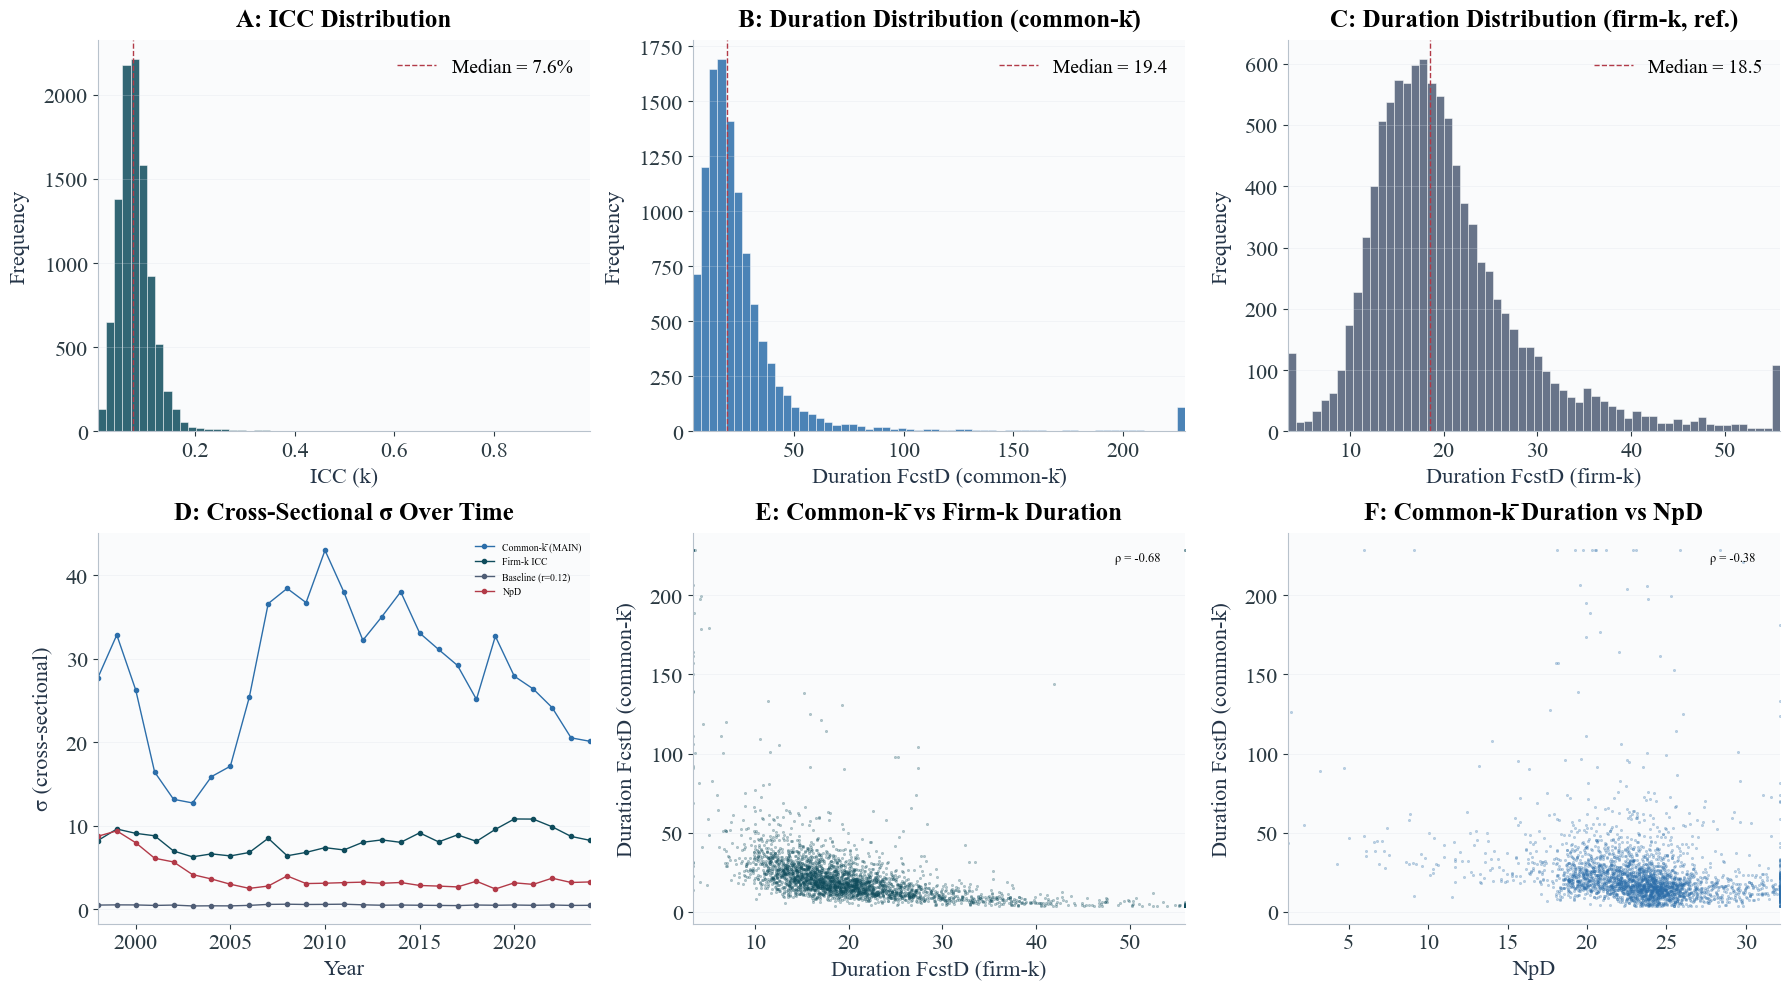

In [11]:
set_global_plot_style()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# A: ICC distribution
conv = df[df["icc_flag"] == "converged"]
axes[0, 0].hist(conv["k_icc"], bins=60, color=COLORS["primary"], edgecolor="white", alpha=0.85)
axes[0, 0].set_xlabel("ICC (k)")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].set_title("A: ICC Distribution")
axes[0, 0].axvline(conv["k_icc"].median(), color=COLORS["accent"], ls="--",
                    label=f'Median = {conv["k_icc"].median():.1%}')
axes[0, 0].legend(frameon=False)
style_axes(axes[0, 0])

# B: Common-k̄ Duration distribution (MAIN)
ck_valid = df[df["Duration_FcstD"].notna()]
axes[0, 1].hist(ck_valid["Duration_FcstD"], bins=60, color=COLORS["blue"], edgecolor="white", alpha=0.85)
axes[0, 1].set_xlabel("Duration FcstD (common-k̄)")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title("B: Duration Distribution (common-k̄)")
axes[0, 1].axvline(ck_valid["Duration_FcstD"].median(), color=COLORS["accent"], ls="--",
                    label=f'Median = {ck_valid["Duration_FcstD"].median():.1f}')
axes[0, 1].legend(frameon=False)
style_axes(axes[0, 1])

# C: Firm-k Duration distribution (reference)
axes[0, 2].hist(conv["Duration_FcstD_firmk"].dropna(), bins=60, color=COLORS["neutral"],
                edgecolor="white", alpha=0.85)
axes[0, 2].set_xlabel("Duration FcstD (firm-k)")
axes[0, 2].set_ylabel("Frequency")
axes[0, 2].set_title("C: Duration Distribution (firm-k, ref.)")
axes[0, 2].axvline(conv["Duration_FcstD_firmk"].median(), color=COLORS["accent"], ls="--",
                    label=f'Median = {conv["Duration_FcstD_firmk"].median():.1f}')
axes[0, 2].legend(frameon=False)
style_axes(axes[0, 2])

# D: σ over time
_np = load_parquet("EQDuration_Netpayout")[["firm_id", "date", "Duration_NetPayout"]]
_mg = df.merge(_np, on=["firm_id", "date"], how="left")
for label, col, color in [
    ("Common-k̄ (MAIN)", "Duration_FcstD", COLORS["blue"]),
    ("Firm-k ICC", "Duration_FcstD_firmk", COLORS["primary"]),
    ("Baseline (r=0.12)", "Duration_FcstD_r012", COLORS["neutral"]),
    ("NpD", "Duration_NetPayout", COLORS["accent"]),
]:
    if col in _mg.columns:
        ys = _mg.groupby("year")[col].std()
        axes[1, 0].plot(ys.index, ys.values, marker="o", ms=3, label=label, color=color)
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("σ (cross-sectional)")
axes[1, 0].set_title("D: Cross-Sectional σ Over Time")
axes[1, 0].legend(frameon=False, fontsize=7)
style_axes(axes[1, 0])

# E: Common-k̄ vs firm-k scatter
_both = df[df["Duration_FcstD"].notna() & df["Duration_FcstD_firmk"].notna()].copy()
if len(_both) > 3000:
    _both_plot = _both.sample(3000, random_state=42)
else:
    _both_plot = _both
from scipy.stats import spearmanr as _sp
_rho_ck_fk, _ = _sp(_both["Duration_FcstD"], _both["Duration_FcstD_firmk"])
axes[1, 1].scatter(_both_plot["Duration_FcstD_firmk"], _both_plot["Duration_FcstD"],
                   s=3, alpha=0.3, color=COLORS["primary"])
axes[1, 1].set_xlabel("Duration FcstD (firm-k)")
axes[1, 1].set_ylabel("Duration FcstD (common-k̄)")
axes[1, 1].set_title("E: Common-k̄ vs Firm-k Duration")
axes[1, 1].text(0.95, 0.95, f"ρ = {_rho_ck_fk:+.2f}",
                transform=axes[1, 1].transAxes, ha="right", va="top", fontsize=9)
style_axes(axes[1, 1])

# F: Common-k̄ Duration vs NpD scatter
_sc_np = _mg[_mg["Duration_FcstD"].notna() & _mg["Duration_NetPayout"].notna()].copy()
if len(_sc_np) > 3000:
    _sc_np_plot = _sc_np.sample(3000, random_state=42)
else:
    _sc_np_plot = _sc_np
_rho_np, _ = _sp(_sc_np["Duration_FcstD"], _sc_np["Duration_NetPayout"])
axes[1, 2].scatter(_sc_np_plot["Duration_NetPayout"], _sc_np_plot["Duration_FcstD"],
                   s=3, alpha=0.3, color=COLORS["blue"])
axes[1, 2].set_xlabel("NpD")
axes[1, 2].set_ylabel("Duration FcstD (common-k̄)")
axes[1, 2].set_title("F: Common-k̄ Duration vs NpD")
axes[1, 2].text(0.95, 0.95, f"ρ = {_rho_np:+.2f}",
                transform=axes[1, 2].transAxes, ha="right", va="top", fontsize=9)
style_axes(axes[1, 2])

fig.tight_layout()
save_figure(fig, "icc_rim_diagnostics")
plt.show()

In [12]:
# FcstD Duration — Summary (common-k̄ main specification)
conv = df[df["icc_flag"] == "converged"]
print("=" * 70)
print("FcstD Duration — SUMMARY (common-k̄ main specification)")
print("=" * 70)

# 1. Industry ROE
print("\n1. Industry ROE (trailing 5-year median):")
ind_roe = df.groupby("trbc_sector")["industry_roe_used"].agg(["mean", "median"])
print(ind_roe.to_string(float_format=lambda x: f"{x:.3f}"))

# 2. ICC distribution
k = conv["k_icc"]
print(f"\n2. ICC distribution (n={len(conv):,}):")
print(f"   Mean: {k.mean():.3%}, Median: {k.median():.3%}, "
      f"P5: {k.quantile(0.05):.3%}, P95: {k.quantile(0.95):.3%}")

# 3. k̄ by year
print(f"\n3. Common k̄ by year:")
print(f"   Pooled median: {df['k_bar'].median():.3%}")
print(f"   Range: {df['k_bar'].min():.3%} – {df['k_bar'].max():.3%}")

# 4. Convergence
print(f"\n4. Convergence: {len(conv):,} / {len(df):,} ({len(conv)/len(df):.1%})")

# 5. Duration comparison (main result)
print("\n5. Duration comparison (main result):")
_np = load_parquet("EQDuration_Netpayout")[["firm_id", "date", "Duration_NetPayout"]]
_mg = df.merge(_np, on=["firm_id", "date"], how="left")
_sub = _mg.dropna(subset=["Duration_FcstD"])
from scipy.stats import spearmanr
print(f"   {'':20s} {'Common k̄':>12s} {'Firm k_icc':>12s} {'r=0.12':>12s}")
for metric_name, metric_fn in [
    ("avg σ", lambda c: _mg.groupby("year")[c].std().mean()),
    ("mean Duration", lambda c: _sub[c].mean()),
]:
    vals = [metric_fn(c) for c in ["Duration_FcstD", "Duration_FcstD_firmk", "Duration_FcstD_r012"]]
    print(f"   {metric_name:20s} {vals[0]:12.3f} {vals[1]:12.3f} {vals[2]:12.3f}")

for metric_name, metric_fn in [
    ("ρ(·, E/P)", lambda c: spearmanr(_sub.dropna(subset=[c, "ROE_fy1"])[c], _sub.dropna(subset=[c, "ROE_fy1"])["ROE_fy1"])[0]),
    ("ρ(·, NpD)", lambda c: spearmanr(_sub.dropna(subset=[c, "Duration_NetPayout"])[c], _sub.dropna(subset=[c, "Duration_NetPayout"])["Duration_NetPayout"])[0]),
    ("ρ(·, baseline)", lambda c: spearmanr(_sub.dropna(subset=[c, "Duration_FcstD_r012"])[c], _sub.dropna(subset=[c, "Duration_FcstD_r012"])["Duration_FcstD_r012"])[0]),
]:
    vals = [metric_fn(c) for c in ["Duration_FcstD", "Duration_FcstD_firmk", "Duration_FcstD_r012"]]
    print(f"   {metric_name:20s} {vals[0]:+12.3f} {vals[1]:+12.3f} {vals[2]:+12.3f}")

# Coverage
n_ck = df["Duration_FcstD"].notna().sum()
n_fk = df["Duration_FcstD_firmk"].notna().sum()
n_bl = df["Duration_FcstD_r012"].notna().sum()
print(f"   {'Coverage':20s} {n_ck/len(df):12.1%} {n_fk/len(df):12.1%} {n_bl/len(df):12.1%}")

# 6. TV share
print(f"\n6. TV share (ICC): mean={conv['TV_share'].mean():.1%}, "
      f"median={conv['TV_share'].median():.1%}")

# 7. RIM price error
pe = conv["price_error_rim"]
print(f"\n7. RIM price error: mean={pe.mean():.1%}, median={pe.median():.1%}, "
      f"P95={pe.quantile(0.95):.1%}")
print(f"   Observations with error > 10%: {(pe > 0.10).sum():,} ({(pe > 0.10).mean():.1%})")

# 8. Negative durations
n_neg_ck = (df.loc[df["Duration_FcstD"].notna(), "Duration_FcstD_commonk_raw"] < 0).sum()
n_neg_fk = (conv["Duration_FcstD_firmk_raw"] < 0).sum()
print(f"\n8. Negative durations:")
print(f"   Common-k̄: {n_neg_ck:,}")
print(f"   Firm-k:   {n_neg_fk:,} ({n_neg_fk/len(conv):.1%})")

# 9. k̄ sensitivity check
print("\n9. k̄ sensitivity (±2pp):")
from scipy.stats import spearmanr as _sp_sens
_k_bar_vals = df["k_bar"].dropna().unique()
for delta, label in [(-0.02, "k̄ - 2pp"), (0.0, "k̄"), (0.02, "k̄ + 2pp")]:
    df[f"_dur_sens_{label}"] = df.apply(
        lambda row: compute_duration_common_k(
            {**row, "k_bar": row.get("k_bar", np.nan) + delta if pd.notna(row.get("k_bar", np.nan)) else np.nan}
        ), axis=1
    )
# Rank correlations between the three
_sens_cols = [f"_dur_sens_{l}" for l in ["k̄ - 2pp", "k̄", "k̄ + 2pp"]]
_sens_sub = df[_sens_cols].dropna()
for i in range(len(_sens_cols)):
    for j in range(i+1, len(_sens_cols)):
        rho, _ = _sp_sens(_sens_sub[_sens_cols[i]], _sens_sub[_sens_cols[j]])
        print(f"   ρ({_sens_cols[i].split('_')[-1]}, {_sens_cols[j].split('_')[-1]}) = {rho:.4f}")
# Clean up temp columns
for c in _sens_cols:
    df.drop(columns=c, inplace=True)

print("\n" + "=" * 70)

FcstD Duration — SUMMARY (common-k̄ main specification)

1. Industry ROE (trailing 5-year median):
                                            mean  median
trbc_sector                                             
Basic Materials                            0.105   0.107
Consumer Cyclicals                         0.138   0.140
Consumer Non-Cyclicals                     0.130   0.128
Energy                                     0.135   0.131
Financials                                 0.097   0.087
Healthcare                                 0.122   0.122
Industrials                                0.123   0.126
Institutions, Associations & Organizations 0.500   0.500
Real Estate                                0.068   0.069
Technology                                 0.153   0.143
Utilities                                  0.096   0.098

2. ICC distribution (n=10,198):
   Mean: 8.411%, Median: 7.609%, P5: 3.275%, P95: 14.302%

3. Common k̄ by year:
   Pooled median: 7.730%
   Range: 6.105% – 10

## 8. Distribution Diagnostics

### 8.1 Sample Funnel

In [13]:
print("Sample Funnel:")
print(funnel_df.to_string(index=False))

Sample Funnel:
                        Step  Firm-years  Dropped
                   Raw input       13796        0
                year >= 1998       13796        0
        NumAnalysts_fy1 >= 3       11470     2326
         EPS_fy1_est not NaN       11466        4
BE > 0 & ME > 0 & shares > 0       11109      357


### 8.2 Duration Distribution

Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/duration_fcstd_distribution.png


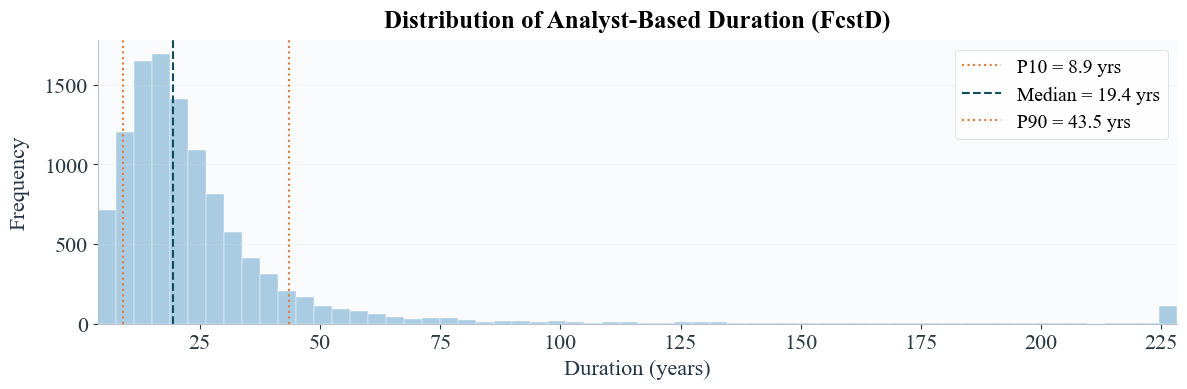

In [14]:
set_global_plot_style()

dur_plot = out.loc[~out["pv_fit_poor"], "Duration_FcstD"].dropna()

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(dur_plot, bins=60, color=COLORS["blue_light"],
        edgecolor="white", linewidth=0.3, density=False)

_p10 = dur_plot.quantile(0.10)
_p50 = dur_plot.quantile(0.50)
_p90 = dur_plot.quantile(0.90)

ax.axvline(_p10, color=COLORS.get("coral", "#e07b39"),
           lw=1.5, ls=":",
           label=f"P10 = {_p10:.1f} yrs")
ax.axvline(_p50, color=COLORS.get("primary", "#1f4e79"),
           lw=1.5, ls="--",
           label=f"Median = {_p50:.1f} yrs")
ax.axvline(_p90, color=COLORS.get("coral", "#e07b39"),
           lw=1.5, ls=":",
           label=f"P90 = {_p90:.1f} yrs")

ax.set_title("Distribution of Analyst-Based Duration (FcstD)")
ax.set_xlabel("Duration (years)")
ax.set_ylabel("Frequency")
ax.legend(frameon=True)
style_axes(ax)
plt.tight_layout()
save_figure(fig, "duration_fcstd_distribution")
plt.show()


### 8.3 Duration Over Time

Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/duration_fcstd_over_time.png


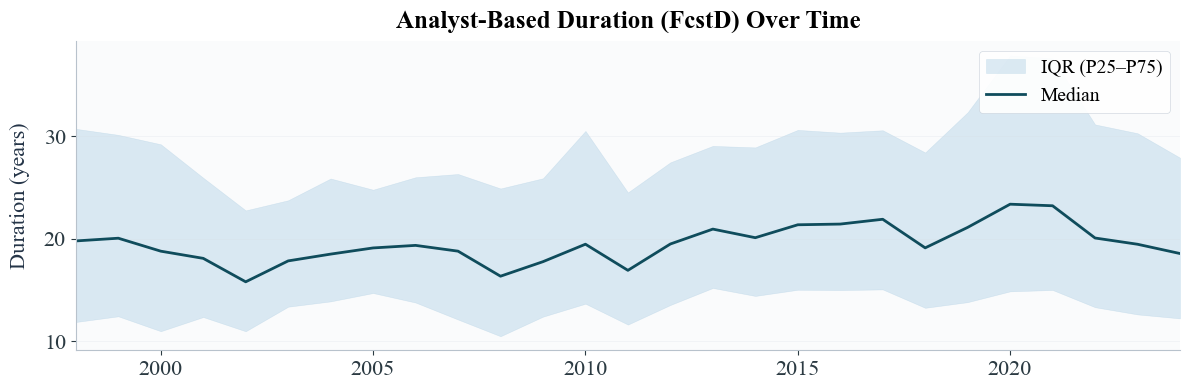

In [15]:
set_global_plot_style()

usable = out.loc[~out["pv_fit_poor"]].copy()
usable["year"] = usable["date"].dt.year

time_stats = usable.groupby("year")["Duration_FcstD"].agg(
    median="median", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75)
).reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(time_stats["year"], time_stats["q25"], time_stats["q75"],
                color=COLORS["blue_light"], alpha=0.4, label="IQR (P25–P75)")
ax.plot(time_stats["year"], time_stats["median"],
        color=COLORS["primary"], lw=2.0, label="Median")

ax.set_title("Analyst-Based Duration (FcstD) Over Time")
ax.set_xlabel("")
ax.set_ylabel("Duration (years)")
ax.set_xlim(1998, usable["year"].max())
style_axes(ax)
ax.legend(loc="upper right", frameon=True, facecolor=(1,1,1,0.82),
          edgecolor="#C4CDD7", framealpha=0.92)
plt.tight_layout()
save_figure(fig, "duration_fcstd_over_time")
plt.show()

### 8.4 Decile Analysis

Firms sorted into 10 deciles by Duration_FcstD each year. We report
mean fundamentals per decile to verify economic plausibility.

In [16]:
dec = usable.copy()
dec["payout_yield"] = (
    dec["DPS_fy1_est"] * dec["shares_outstanding"] / dec["ME"]
)

dec["dur_decile"] = dec.groupby("year")["Duration_FcstD"].transform(
    lambda x: pd.qcut(x, 10, labels=range(1, 11), duplicates="drop")
)
dec["dur_decile"] = pd.to_numeric(dec["dur_decile"], errors="coerce")

decile_table = (
    dec.groupby("dur_decile")
    .agg(
        mean_duration=("Duration_FcstD", "mean"),
        mean_payout_yield=("payout_yield", "mean"),
        n_obs=("Duration_FcstD", "count"),
    )
    .reset_index()
)
decile_table["mean_payout_yield"] = decile_table["mean_payout_yield"] * 100  # percent

print("Decile Analysis: Duration vs Payout Yield")
print(decile_table.to_string(index=False, float_format="{:.2f}".format))

Decile Analysis: Duration vs Payout Yield
 dur_decile  mean_duration  mean_payout_yield  n_obs
          1           6.65               2.21   1124
          2          10.70               2.94   1108
          3          13.35               3.02   1108
          4          15.74               3.06   1107
          5          18.23               2.96   1116
          6          21.07               3.24   1102
          7          24.43               3.36   1106
          8          28.97               3.36   1109
          9          36.43               4.95   1107
         10          88.51            2336.22   1122


### 8.5 Correlation with Net-Payout Duration and Fundamentals

Convergent validity: FcstD vs NpD, E/P, B/M.

In [17]:
# Inspect columns before merge
print("out columns:", list(out.columns))
print("np_out Duration-like columns:", [c for c in np_out.columns if "uration" in c or "dur" in c.lower()])

# Merge with NetPayout duration
np_dur = np_out[["firm_id", "year", "Duration_NetPayout"]].copy()
np_dur = np_dur.rename(columns={"Duration_NetPayout": "Duration_NP"})

corr_df = out.copy()
corr_df["year"] = corr_df["date"].dt.year
corr_df = corr_df.merge(np_dur, on=["firm_id", "year"], how="left")

# Merge diagnostics
n_np_matched = corr_df["Duration_NP"].notna().sum()
n_total = len(corr_df)
print(f"\nMerge diagnostics:")
print(f"  Rows with non-null Duration_NP: {n_np_matched:,} / {n_total:,} ({n_np_matched/n_total:.1%})")

corr_usable_all = corr_df.loc[~corr_df["pv_fit_poor"]].copy()
n_usable_np = corr_usable_all["Duration_NP"].notna().sum()
n_usable = len(corr_usable_all)
print(f"  Usable FcstD sample with matched NP: {n_usable_np:,} / {n_usable:,} ({n_usable_np/n_usable:.1%})")

if n_usable_np / n_usable < 0.50:
    print(f"\n  ⚠ Coverage warning: Only {n_usable_np/n_usable:.1%} of usable FcstD firm-years")
    print(f"    have a matched NP duration. This is likely due to different sample periods")
    print(f"    or filter differences between the analyst-based and net-payout notebooks.")

# Construct additional variables
corr_df["BM"] = corr_df["BE"] / corr_df["ME"]
corr_df["EP"] = (corr_df["EPS_fy1_est"] * corr_df["shares_outstanding"]) / corr_df["ME"]
corr_df["log_ME"] = np.log(corr_df["ME"])

# Filter usable
corr_usable = corr_df.loc[~corr_df["pv_fit_poor"]].copy()

corr_vars = ["Duration_FcstD", "Duration_NP", "log_ME", "BM", "EP"]

# Pearson
corr_matrix = corr_usable[corr_vars].corr()
print("\nPearson Correlation Matrix (usable sample):")
print(corr_matrix.to_string(float_format="{:.3f}".format))

# Spearman
spearman = corr_usable[corr_vars].corr(method="spearman")
print("\nSpearman Rank Correlation:")
print(spearman.to_string(float_format="{:.3f}".format))

# Focal correlations
both_valid = corr_usable[["Duration_FcstD", "Duration_NP"]].dropna()
print(f"\nFocal: Corr(FcstD, NP) on {len(both_valid):,} overlapping firm-years:")
print(f"  Pearson:  {both_valid['Duration_FcstD'].corr(both_valid['Duration_NP']):.3f}")
print(f"  Spearman: {both_valid['Duration_FcstD'].corr(both_valid['Duration_NP'], method='spearman'):.3f}")

out columns: ['firm_id', 'date', 'year', 'trbc_sector', 'CFPS_fy1_est', 'CFPS_fy2_est', 'CFPS_fy3_est', 'EPS_fy1_est', 'EPS_fy2_est', 'EPS_fy3_est', 'DPS_fy1_est', 'DPS_fy2_est', 'DPS_fy3_est', 'NumAnalysts_fy1', 'shares_outstanding', 'BE', 'ME', 'ROE_fy1', 'ROE_fy2', 'ROE_fy3', 'b_fy1', 'b_fy2', 'b_fy3', 'industry_roe_used', 'k_icc', 'k_bar', 'icc_flag', 'PV_forecast', 'TV', 'TV_share', 'pv_fit_poor', 'price_error_rim', 'Duration_FcstD_commonk_raw', 'Duration_FcstD', 'Duration_FcstD_firmk_raw', 'Duration_FcstD_firmk', 'PV_forecast_r012', 'TV_r012', 'pv_fit_poor_r012', 'Duration_FcstD_r012_raw', 'Duration_FcstD_r012']
np_out Duration-like columns: ['Duration_NetPayout', 'Duration_NP_strict', 'duration_usable', 'duration_usable_strict']

Merge diagnostics:
  Rows with non-null Duration_NP: 8,794 / 11,109 (79.2%)
  Usable FcstD sample with matched NP: 8,794 / 11,109 (79.2%)

Pearson Correlation Matrix (usable sample):
                Duration_FcstD  Duration_NP  log_ME     BM     EP
Dura

Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/coverage_fcstd_annual.png


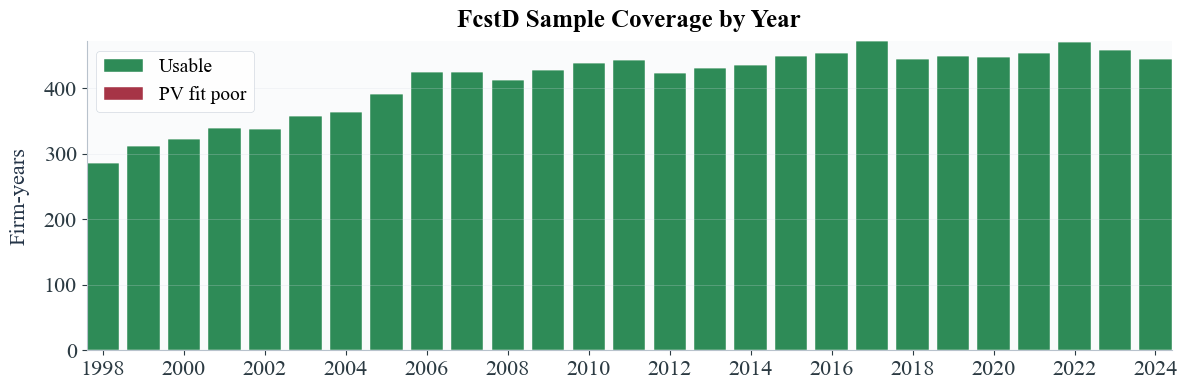

In [18]:
set_global_plot_style()

# Coverage by year: usable vs pv_fit_poor
_cov = out.copy()
_cov["year"] = _cov["date"].dt.year
_cov_grp = (
    _cov.groupby("year")
    .agg(
        usable=("pv_fit_poor", lambda s: int((~s).sum())),
        poor=("pv_fit_poor", lambda s: int(s.sum())),
    )
    .reset_index()
)
_cov_grp = _cov_grp[(_cov_grp["year"] >= 1998) & (_cov_grp["year"] <= 2024)]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(_cov_grp["year"], _cov_grp["usable"],
       color=COLORS["green"], edgecolor="white", linewidth=0.3,
       label="Usable")
ax.bar(_cov_grp["year"], _cov_grp["poor"],
       bottom=_cov_grp["usable"],
       color=COLORS["red"], edgecolor="white", linewidth=0.3,
       label="PV fit poor")

ax.set_title("FcstD Sample Coverage by Year")
ax.set_xlabel("")
ax.set_ylabel("Firm-years")
ax.set_xticks(range(1998, 2025, 2))
style_axes(ax)
ax.legend(loc="upper left", frameon=True, facecolor=(1, 1, 1, 0.82),
          edgecolor="#C4CDD7", framealpha=0.92)
plt.tight_layout()
save_figure(fig, "coverage_fcstd_annual")
plt.show()


Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/tv_share_fcstd_hist.png


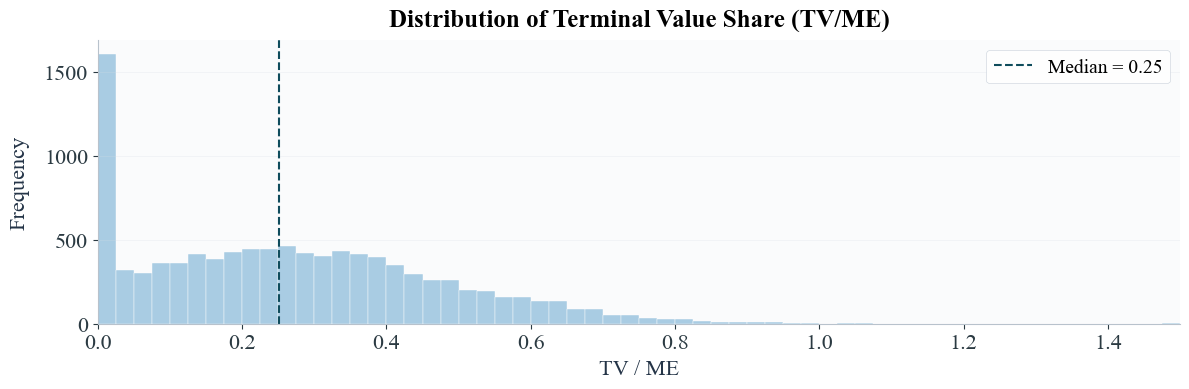

In [19]:
set_global_plot_style()

# Terminal value share: TV / ME for usable observations
_tv = out.loc[~out["pv_fit_poor"], ["TV", "ME"]].dropna()
_tv_share = (_tv["TV"] / _tv["ME"]).replace([np.inf, -np.inf], np.nan).dropna()
_tv_share_clip = _tv_share.clip(lower=0.0, upper=1.5)
_median_tv = _tv_share.median()

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(_tv_share_clip, bins=60, range=(0.0, 1.5),
        color=COLORS["blue_light"], edgecolor="white", linewidth=0.3)
ax.axvline(_median_tv, color=COLORS["primary"], lw=1.5, ls="--",
           label=f"Median = {_median_tv:.2f}")

ax.set_title("Distribution of Terminal Value Share (TV/ME)")
ax.set_xlabel("TV / ME")
ax.set_ylabel("Frequency")
ax.set_xlim(0.0, 1.5)
style_axes(ax)
ax.legend(loc="upper right", frameon=True, facecolor=(1, 1, 1, 0.82),
          edgecolor="#C4CDD7", framealpha=0.92)
plt.tight_layout()
save_figure(fig, "tv_share_fcstd_hist")
plt.show()


Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/fcstd_decile_payout_yield.png


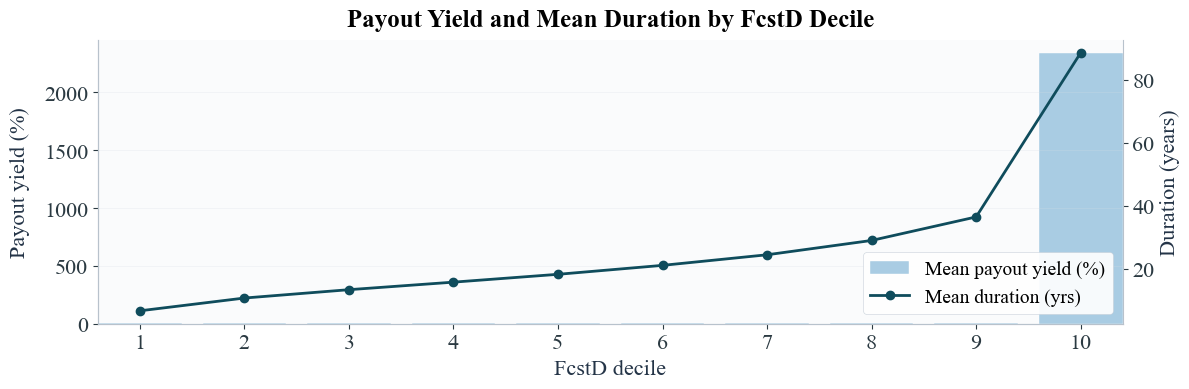

In [20]:
set_global_plot_style()

# Use existing `dec` DataFrame from Cell 22 decile analysis
_dec_plot = (
    dec.dropna(subset=["dur_decile"])
    .groupby("dur_decile")
    .agg(
        mean_duration=("Duration_FcstD", "mean"),
        mean_payout_yield=("payout_yield", "mean"),
    )
    .reset_index()
)
_dec_plot["mean_payout_yield_pct"] = _dec_plot["mean_payout_yield"] * 100

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(_dec_plot["dur_decile"], _dec_plot["mean_payout_yield_pct"],
       color=COLORS["blue_light"], edgecolor="white", linewidth=0.3,
       label="Mean payout yield (%)")
ax.set_xlabel("FcstD decile")
ax.set_ylabel("Payout yield (%)")
ax.set_xticks(range(1, 11))
style_axes(ax)

ax2 = ax.twinx()
ax2.plot(_dec_plot["dur_decile"], _dec_plot["mean_duration"],
         color=COLORS["primary"], lw=2.0, marker="o",
         label="Mean duration (yrs)")
ax2.set_ylabel("Duration (years)")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_color("#B8C2CC")
ax2.tick_params(axis="y", labelsize=16)

ax.set_title("Payout Yield and Mean Duration by FcstD Decile")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="lower right",
          frameon=True, facecolor=(1, 1, 1, 0.82),
          edgecolor="#C4CDD7", framealpha=0.92)
plt.tight_layout()
save_figure(fig, "fcstd_decile_payout_yield")
plt.show()


Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/fcstd_npd_scatter.png


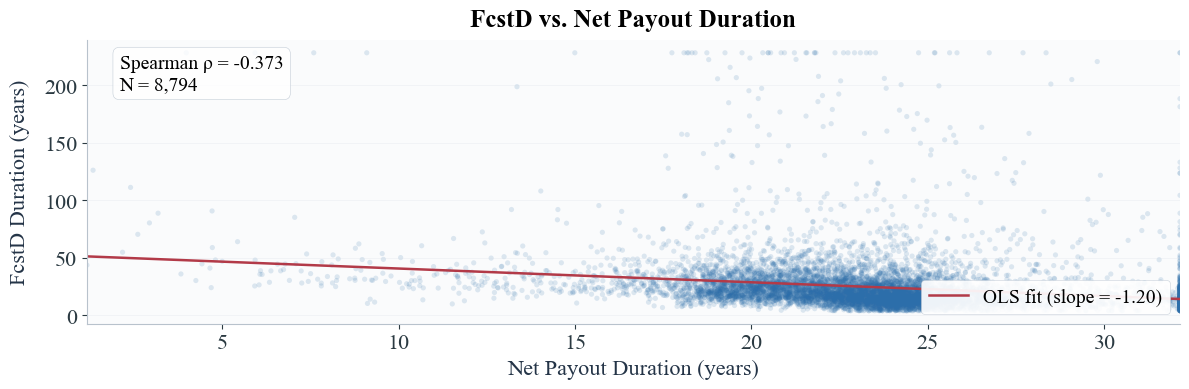

In [21]:
set_global_plot_style()

# Scatter FcstD vs NpD using corr_df from Cell 24
_sc = corr_df.loc[~corr_df["pv_fit_poor"], ["Duration_FcstD", "Duration_NP"]].dropna()

_rho_s = _sc["Duration_FcstD"].corr(_sc["Duration_NP"], method="spearman")

# Linear regression line
_x = _sc["Duration_NP"].values
_y = _sc["Duration_FcstD"].values
_slope, _intercept = np.polyfit(_x, _y, 1)
_x_line = np.linspace(_x.min(), _x.max(), 100)
_y_line = _slope * _x_line + _intercept

fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(_sc["Duration_NP"], _sc["Duration_FcstD"],
           alpha=0.15, s=14, color=COLORS["blue"],
           edgecolors="none")
ax.plot(_x_line, _y_line, color=COLORS["accent"], lw=1.8,
        label=f"OLS fit (slope = {_slope:.2f})")

ax.text(0.03, 0.95,
        f"Spearman ρ = {_rho_s:.3f}\nN = {len(_sc):,}",
        transform=ax.transAxes, va="top", ha="left",
        fontsize=14,
        bbox=dict(boxstyle="round,pad=0.35",
                  facecolor=(1, 1, 1, 0.82),
                  edgecolor="#C4CDD7"))

ax.set_title("FcstD vs. Net Payout Duration")
ax.set_xlabel("Net Payout Duration (years)")
ax.set_ylabel("FcstD Duration (years)")
style_axes(ax)
ax.legend(loc="lower right", frameon=True, facecolor=(1, 1, 1, 0.82),
          edgecolor="#C4CDD7", framealpha=0.92)
plt.tight_layout()
save_figure(fig, "fcstd_npd_scatter")
plt.show()


Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/roe_reversion_example.png


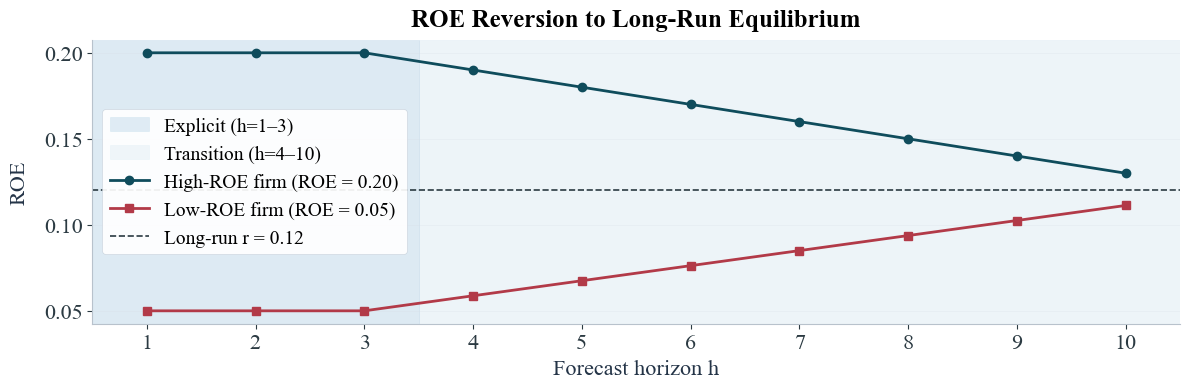

In [22]:
set_global_plot_style()

# Illustrative ROE reversion schematic
_r_bar = 0.12
_h = np.arange(1, 11)

def _roe_path(roe0: float) -> np.ndarray:
    path = np.empty_like(_h, dtype=float)
    for i, h in enumerate(_h):
        if h <= 3:
            path[i] = roe0
        else:
            alpha = (h - 3) / 8.0
            path[i] = (1 - alpha) * roe0 + alpha * _r_bar
    return path

_high = _roe_path(0.20)
_low = _roe_path(0.05)

fig, ax = plt.subplots(figsize=(12, 4))

# Shaded regions
ax.axvspan(0.5, 3.5, color=COLORS["blue_light"], alpha=0.35, label="Explicit (h=1–3)")
ax.axvspan(3.5, 10.5, color=COLORS["blue_light"], alpha=0.15, label="Transition (h=4–10)")

ax.plot(_h, _high, color=COLORS["primary"], lw=2.0, marker="o",
        label="High-ROE firm (ROE = 0.20)")
ax.plot(_h, _low, color=COLORS["accent"], lw=2.0, marker="s",
        label="Low-ROE firm (ROE = 0.05)")

ax.axhline(_r_bar, color=COLORS["reference"], lw=1.2, ls="--",
           label=f"Long-run r = {_r_bar:.2f}")

ax.set_title("ROE Reversion to Long-Run Equilibrium")
ax.set_xlabel("Forecast horizon h")
ax.set_ylabel("ROE")
ax.set_xticks(_h)
ax.set_xlim(0.5, 10.5)
style_axes(ax)
ax.legend(loc="center left", frameon=True, facecolor=(1, 1, 1, 0.82),
          edgecolor="#C4CDD7", framealpha=0.92)
plt.tight_layout()
save_figure(fig, "roe_reversion_example")
plt.show()


In [23]:
# GRAFIK-ÜBERSICHT: FcstD figures
_fcstd_figs = [
    "duration_fcstd_distribution",
    "duration_fcstd_over_time",
    "coverage_fcstd_annual",
    "tv_share_fcstd_hist",
    "fcstd_decile_payout_yield",
    "fcstd_npd_scatter",
    "roe_reversion_example",
]

print("GRAFIK-ÜBERSICHT – EQDuration_AnalystBased")
print(f"Directory: {NOTEBOOK_GRAPH_DIR}")
print("-" * 60)
for _name in _fcstd_figs:
    _p = NOTEBOOK_GRAPH_DIR / f"{_name}.png"
    _mark = "✓" if _p.exists() else "✗"
    print(f"  [{_mark}] {_name}.png")
print("-" * 60)
_n_ok = sum((NOTEBOOK_GRAPH_DIR / f"{n}.png").exists() for n in _fcstd_figs)
print(f"Total: {_n_ok}/{len(_fcstd_figs)} figures present")


GRAFIK-ÜBERSICHT – EQDuration_AnalystBased
Directory: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased
------------------------------------------------------------
  [✓] duration_fcstd_distribution.png
  [✓] duration_fcstd_over_time.png
  [✓] coverage_fcstd_annual.png
  [✓] tv_share_fcstd_hist.png
  [✓] fcstd_decile_payout_yield.png
  [✓] fcstd_npd_scatter.png
  [✓] roe_reversion_example.png
------------------------------------------------------------
Total: 7/7 figures present


## 9. Summary Statistics

In [24]:
usable_final = out.loc[~out["pv_fit_poor"]].copy()
dur = usable_final["Duration_FcstD"].dropna()

print("=" * 50)
print("FINAL SUMMARY")
print("=" * 50)
print(f"Output shape:       {out.shape}")
print(f"Usable firm-years:  {len(usable_final):,} / {len(out):,} ({len(usable_final)/len(out):.1%})")
print(f"pv_fit_poor rate:   {out['pv_fit_poor'].mean():.1%}")
print(f"\nWinsorization bounds (common-k̄): P1 = {p1_ck:.2f}, P99 = {p99_ck:.2f}")
print(f"\nDuration_FcstD (common-k̄) percentiles (usable sample):")
for p, label in [(0.10, "P10"), (0.25, "P25"), (0.50, "P50"), (0.75, "P75"), (0.90, "P90")]:
    print(f"  {label}: {dur.quantile(p):.2f}")
print(f"  Mean: {dur.mean():.2f}")
print(f"  Std:  {dur.std():.2f}")

# Updated correlations with NP
print(f"\nCorr(Duration_FcstD, Duration_NP):")
both = corr_usable[["Duration_FcstD", "Duration_NP"]].dropna()
print(f"  Pearson:  {both['Duration_FcstD'].corr(both['Duration_NP']):.3f}")
print(f"  Spearman: {both['Duration_FcstD'].corr(both['Duration_NP'], method='spearman'):.3f}")
print(f"  (based on {len(both):,} overlapping firm-years)")

FINAL SUMMARY
Output shape:       (11109, 41)
Usable firm-years:  11,109 / 11,109 (100.0%)
pv_fit_poor rate:   0.0%

Winsorization bounds (common-k̄): P1 = 3.74, P99 = 228.36

Duration_FcstD (common-k̄) percentiles (usable sample):
  P10: 8.88
  P25: 13.28
  P50: 19.44
  P75: 28.71
  P90: 43.54
  Mean: 26.45
  Std:  29.62

Corr(Duration_FcstD, Duration_NP):
  Pearson:  -0.195
  Spearman: -0.373
  (based on 8,794 overlapping firm-years)
